<a href="https://colab.research.google.com/github/mahsajahanbakhsh/Hyperspectral-Image-Classification-using-SVM-RBF-Sigmoid-poly-/blob/main/SVC_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Indian pines hyperspecral dataset:

### Useful imports

In [1]:
import keras
from keras.layers import Conv2D, Conv3D, Flatten, Dense, Reshape, BatchNormalization
from keras.layers import Dropout, Input
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
# from keras.utils import np_utils

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

from operator import truediv

from plotly.offline import init_notebook_mode

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os

## Mounting Colab
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls


drive  sample_data


In [3]:

## Importing Library.
from scipy.io import loadmat

## Path to the folder in Google Drive containing the .mat files
data_path = '/content/drive/My Drive/Colab'

## Import DATASET loaded from google drive
dataset = sio.loadmat(os.path.join(data_path, 'Salinas_corrected.mat'))['salinas_corrected']
ground_truth = labels = sio.loadmat(os.path.join(data_path, 'Salinas_gt.mat'))['salinas_gt']


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Colab/Salinas_corrected.mat'

In [4]:

#The dimensions of the data.
print(f'Dataset: {dataset.shape}\nGround Truth: {ground_truth.shape}')
#print(f'Dataset1: {dataset1.shape}\nGround Truth1: {ground_truth1.shape}')

NameError: name 'dataset' is not defined

Data visualization:

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def plot_band(dataset):
    plt.figure(figsize=(8, 6))
    band_no = np.random.randint(dataset.shape[2])
    plt.imshow(dataset[:,:, band_no], cmap='viridis')
    plt.title(f'Band-{band_no}', fontsize=14)
    plt.axis('off')
    plt.colorbar()
    plt.show()

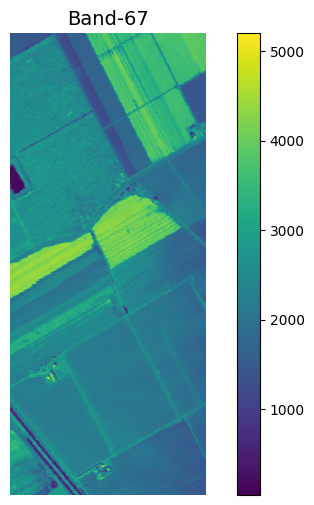

In [ ]:
plot_band(dataset)

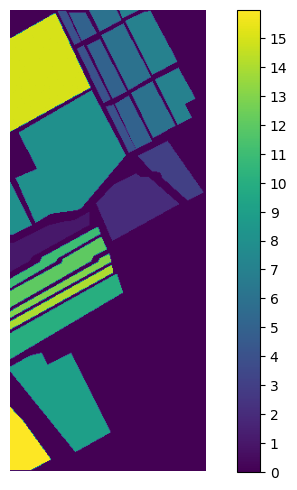

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(ground_truth, cmap='viridis')
plt.axis('off')
plt.colorbar(ticks= range(0,16))
plt.show()

### Extracting Band Information:

In [ ]:
from tqdm import tqdm
import pandas as pd

def extract_pixels(dataset, ground_truth):
    df = pd.DataFrame()
    for i in tqdm(range(dataset.shape[2])):
        df = pd.concat([df, pd.DataFrame(dataset[:, :, i].ravel())], axis=1)
    df = pd.concat([df, pd.DataFrame(ground_truth.ravel())], axis=1)
    df.columns = [f'band-{i}' for i in range(1, 1+dataset.shape[2])]+['class']
    return df

df = extract_pixels(dataset, ground_truth)
df.head()

100%|██████████| 204/204 [00:01<00:00, 141.40it/s]


,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-196,band-197,band-198,band-199,band-200,band-201,band-202,band-203,band-204,class
0,290,381,585,1041,1316,1397,1319,1462,1643,1683,...,96,109,93,54,79,54,36,11,17,0
1,290,381,519,1041,1316,1352,1319,1462,1643,1683,...,94,111,96,56,83,56,36,11,15,0
2,290,381,585,1041,1286,1352,1300,1412,1614,1644,...,88,107,89,54,81,54,30,11,11,0
3,290,381,585,999,1316,1374,1280,1380,1584,1631,...,86,105,85,56,75,50,30,11,19,0
4,219,381,585,999,1286,1352,1261,1396,1555,1618,...,83,105,83,48,75,50,24,9,17,0


In [ ]:
df

,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-196,band-197,band-198,band-199,band-200,band-201,band-202,band-203,band-204,class
0,290,381,585,1041,1316,1397,1319,1462,1643,1683,...,96,109,93,54,79,54,36,11,17,0
1,290,381,519,1041,1316,1352,1319,1462,1643,1683,...,94,111,96,56,83,56,36,11,15,0
2,290,381,585,1041,1286,1352,1300,1412,1614,1644,...,88,107,89,54,81,54,30,11,11,0
3,290,381,585,999,1316,1374,1280,1380,1584,1631,...,86,105,85,56,75,50,30,11,19,0
4,219,381,585,999,1286,1352,1261,1396,1555,1618,...,83,105,83,48,75,50,24,9,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111099,376,405,608,1043,1382,1446,1376,1526,1719,1760,...,121,150,124,72,112,76,46,17,27,0
111100,305,489,608,1086,1353,1446,1357,1510,1704,1760,...,126,144,122,76,106,74,40,13,21,0
111101,447,405,674,1128,1382,1446,1357,1493,1690,1760,...,117,146,120,72,108,76,42,11,23,0
111102,447,405,674,1086,1382,1424,1357,1493,1704,1734,...,123,144,122,80,110,78,42,17,27,0


In [ ]:
df.to_csv('Dataset.csv', index=False)

In [ ]:
def plot_signature(df):
    n_bands = df.shape[1] - 1  # number of spectral bands (all columns except 'class')
    plt.figure(figsize=(12, 6))
    pixel_no = np.random.randint(df.shape[0])
    plt.plot(range(1, n_bands + 1), df.iloc[pixel_no, :-1].values.tolist(), 'b--',
             label=f'Class - {df.iloc[pixel_no, -1]}')
    plt.legend()
    plt.title(f'Pixel({pixel_no}) signature', fontsize=14)
    plt.xlabel('Band Number', fontsize=14)
    plt.ylabel('Pixel Intensity', fontsize=14)
    plt.show()


In [ ]:
plot_signature(df)

In [ ]:
ls

Dataset.csv  Indian_pines_corrected.mat    Indian_pines_gt.mat
drive/       Indian_pines_corrected.mat.1  sample_data/


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
df.sample(6)

,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-196,band-197,band-198,band-199,band-200,band-201,band-202,band-203,band-204,class
39900,237,408,745,1183,1525,1628,1550,1741,2022,2111,...,165,199,163,101,147,100,52,21,34,3
27682,300,466,593,996,1292,1327,1276,1380,1587,1616,...,83,107,93,58,81,51,22,14,14,4
54339,447,566,857,1348,1673,1808,1783,2006,2330,2434,...,171,211,170,105,152,108,60,24,33,11
63197,374,483,739,1221,1529,1560,1533,1679,1950,2022,...,164,196,171,105,151,108,54,19,31,12
83839,377,570,794,1303,1643,1782,1703,1906,2226,2332,...,207,247,208,137,196,136,75,26,41,0
66401,361,479,801,1298,1643,1811,1741,2022,2356,2487,...,215,251,221,133,195,132,68,26,43,0


In [ ]:
print(f'Shape of the data: {df.shape}')

Shape of the data: (111104, 205)


### Band Information visualization:

In [ ]:
print(f"Unique Class Labels: {df.loc[:, 'class'].unique()}")

Unique Class Labels: [ 0  6  7  4  5 15  8  3  2  1 11 12 13 14 10  9 16]


In [ ]:
df.loc[:, 'class'].value_counts()

0     56975
8     11271
15     7268
9      6203
6      3959
2      3726
7      3579
10     3278
5      2678
1      2009
3      1976
12     1927
16     1807
4      1394
14     1070
11     1068
13      916
Name: class, dtype: int64

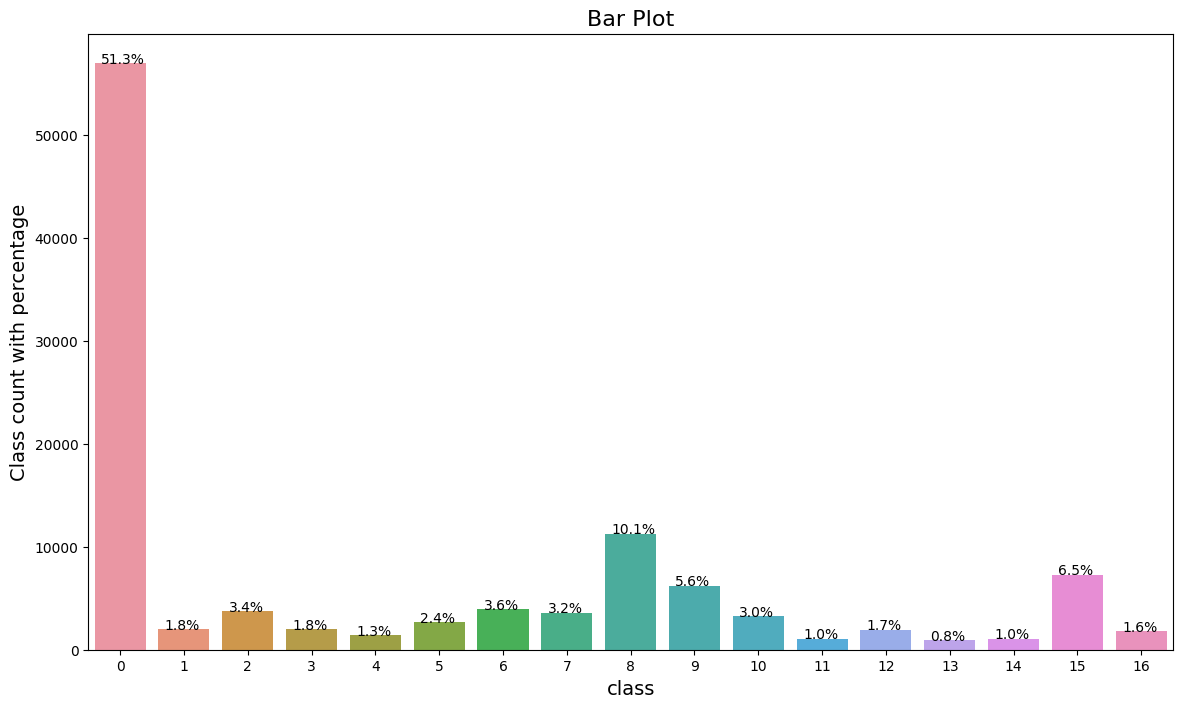

In [ ]:

plt.figure(figsize=(14, 8))

ax = sns.countplot(x='class', data=df[['class']])

for p in ax.patches:
        ax.annotate('{:.1f}%'.format(100*p.get_height()/df.shape[0]), (p.get_x()+0.1, p.get_height()+5))
#ax.yaxis.set_major_locator(ticker.LinearLocator(11))

plt.ylabel('Class count with percentage', fontsize=14)

plt.xlabel('class', fontsize=14)

plt.title('Bar Plot', fontsize=16)

plt.show()

In [ ]:
# Visualizing the pixel
n_bands = df.shape[1] - 1
plt.matshow(df.iloc[1, :-1].values.reshape(1, n_bands), cmap='jet');


In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def _grid_shape(n):
    """Find a (rows, cols) grid close to square that exactly reshapes n values."""
    for rows in range(int(n ** 0.5), 0, -1):
        if n % rows == 0:
            return rows, n // rows
    return 1, n

def plot_pixel(pixel, n):
    rows, cols = _grid_shape(len(pixel))
    ax = plt.gca()
    im = ax.imshow(pixel.reshape(rows, cols), cmap='jet')
    plt.title(f'pixel - {n}')
    plt.axis('off')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    plt.show()


In [ ]:
plt.figure(figsize=(8, 4))

rand_n = np.random.randint(df.shape[0])

plot_pixel(df.iloc[rand_n, :-1].values, rand_n)

In [ ]:
plt.figure(figsize=(16, 6))
n = int(input('Enter the band Number (1-{}): '.format(df.shape[1] - 1)))
sns.boxplot(x=df["class"], y=df[f"band-{n}"], width=0.3);
plt.title('Box Plot', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel(f'Band-{n}', fontsize=14)
plt.show()


In [ ]:
print(f"Details of Band - {n}: \n\n{df['band-'+str(n)].describe()}")

Details of Band - 79: 

count    111104.000000
mean       1619.128456
std         475.521321
min          23.000000
25%        1326.000000
50%        1510.000000
75%        1783.000000
max        3346.000000
Name: band-79, dtype: float64


In [ ]:
plt.figure(figsize=(16, 6))
sns.histplot(df[f'band-{n}'], color='mediumSpringGreen', bins=100, kde=True, alpha=0.4)
plt.xlabel('Band - ' + str(n), fontsize=14)
plt.title('Distribution Plot of Band - ' + str(n), fontsize=16)
plt.show()


### Implemetation of Dimensionality reduction using truncated SVD

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# !pip install seaborn
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('Dataset.csv')
df

,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-196,band-197,band-198,band-199,band-200,band-201,band-202,band-203,band-204,class
0,290,381,585,1041,1316,1397,1319,1462,1643,1683,...,96,109,93,54,79,54,36,11,17,0
1,290,381,519,1041,1316,1352,1319,1462,1643,1683,...,94,111,96,56,83,56,36,11,15,0
2,290,381,585,1041,1286,1352,1300,1412,1614,1644,...,88,107,89,54,81,54,30,11,11,0
3,290,381,585,999,1316,1374,1280,1380,1584,1631,...,86,105,85,56,75,50,30,11,19,0
4,219,381,585,999,1286,1352,1261,1396,1555,1618,...,83,105,83,48,75,50,24,9,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111099,376,405,608,1043,1382,1446,1376,1526,1719,1760,...,121,150,124,72,112,76,46,17,27,0
111100,305,489,608,1086,1353,1446,1357,1510,1704,1760,...,126,144,122,76,106,74,40,13,21,0
111101,447,405,674,1128,1382,1446,1357,1493,1690,1760,...,117,146,120,72,108,76,42,11,23,0
111102,447,405,674,1086,1382,1424,1357,1493,1704,1734,...,123,144,122,80,110,78,42,17,27,0


In [ ]:
X = df.iloc[:, :-1].values

y = df.iloc[:, -1].values



In [ ]:
X.shape, y.shape

((111104, 204), (111104,))

In [ ]:
#kpca = KernelPCA(n_components = 50, kernel='poly', eigen_solver='arpack')
kpca = PCA(n_components=50, whiten=True)
#pca = PCA(n_components=numComponents, svd_solver='arpack')
principalComponents = kpca.fit_transform(X)

principalComponents.shape

(111104, 50)

In [ ]:
X_train, X_test, y_train, y_test, indices_train, indices_test  = train_test_split(principalComponents, y,  range(X.shape[0]),
                                                                                  test_size = 0.15, random_state = 11)

In [ ]:
X_train.shape, X_test.shape

((94438, 50), (16666, 50))

##Apply SVC with kernel 'RBF' and Degree 11 and gamma 'scale'




In [ ]:

svm = SVC(kernel='rbf', degree = 11, gamma='scale', cache_size=1024*7)
svm.fit(X_train, y_train)

SVC(cache_size=7168, degree=11)

In [ ]:
y_pred = svm.predict(X_test)

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f'Accuracy: {accuracy_score(y_test, y_pred)*100}%')


Accuracy: 91.47365894635784%


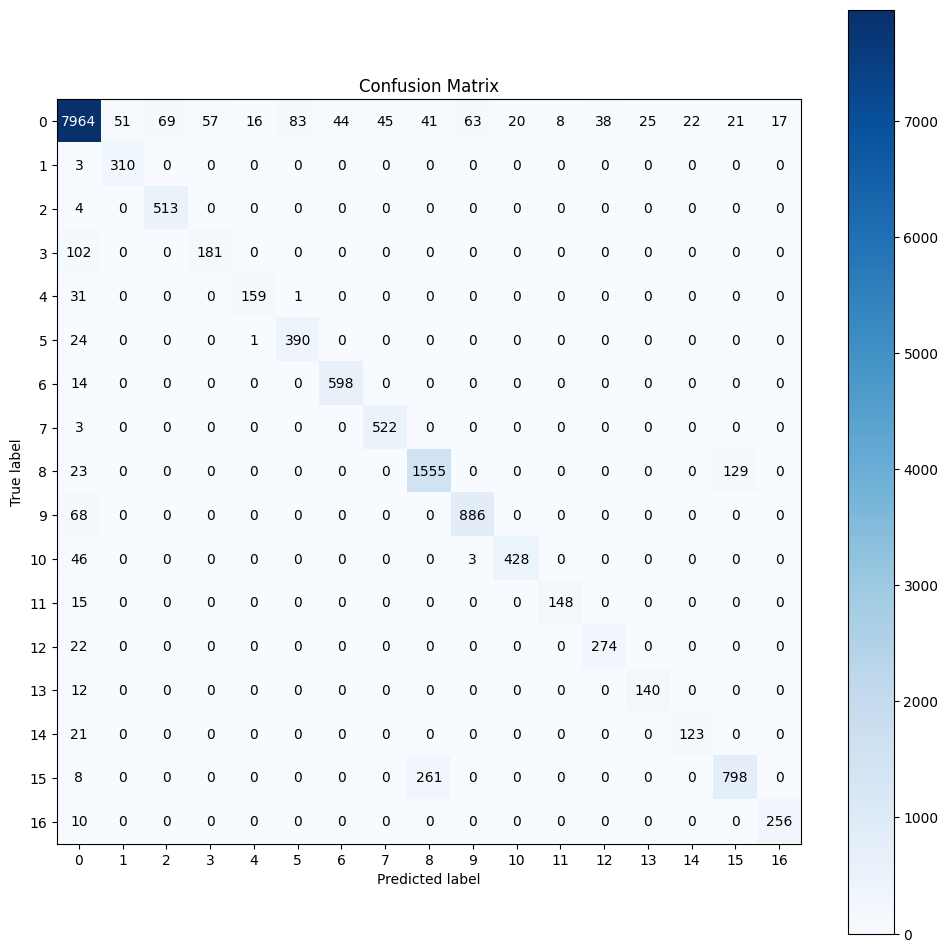

In [ ]:

! pip install -q scikit-plot

import scikitplot as skplt

skplt.metrics.plot_confusion_matrix(
    y_test,
    y_pred,
    figsize=(12,12));

In [ ]:
# print(confusion_matrix(y_test,y_pred))
print('Classification report:\n',classification_report(y_test,y_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      8584
           1       0.86      0.99      0.92       313
           2       0.88      0.99      0.93       517
           3       0.76      0.64      0.69       283
           4       0.90      0.83      0.87       191
           5       0.82      0.94      0.88       415
           6       0.93      0.98      0.95       612
           7       0.92      0.99      0.96       525
           8       0.84      0.91      0.87      1707
           9       0.93      0.93      0.93       954
          10       0.96      0.90      0.93       477
          11       0.95      0.91      0.93       163
          12       0.88      0.93      0.90       296
          13       0.85      0.92      0.88       152
          14       0.85      0.85      0.85       144
          15       0.84      0.75      0.79      1067
          16       0.94      0.96      0.95       266

  

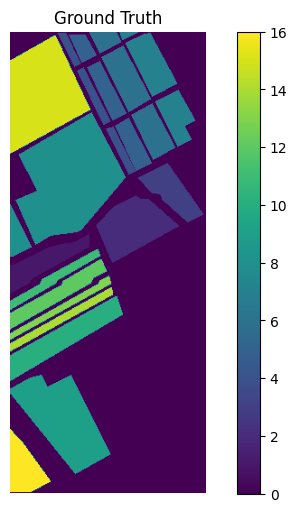

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(df.iloc[:, -1].values.reshape((512, 217)))
plt.colorbar()
plt.axis('off')
plt.title('Ground Truth')
plt.savefig('ground_truth.png')
plt.show()

In [ ]:
# !pip install tqdm
from tqdm import tqdm
pre = y_pred

clmap = [0]*X.shape[0]

for i in tqdm(range(len(indices_train))):
    clmap[indices_train[i]] = y[indices_train[i]]

for i in tqdm(range(len(indices_test))):
    clmap[indices_test[i]] = pre[i]

100%|██████████| 16666/16666 [00:00<00:00, 1448931.90it/s]


In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(np.array(clmap).reshape((512, 217)))
plt.colorbar()
plt.axis('off')
plt.title('Classification Map (PCA + SVC(kernel: rbf))')
plt.savefig('Classification_map_rbf.png')
plt.show()


##Apply SVC with C:1 kernel: 'sigmoid' and Degree: 8 and gamma 'scale'


In [ ]:

svm2 = SVC(kernel='sigmoid', degree = 8, gamma='scale', cache_size=1024*7)
svm2.fit(X_train, y_train)

SVC(cache_size=7168, degree=8, kernel='sigmoid')

In [ ]:
y_pred2 = svm2.predict(X_test)

In [ ]:
print(f'Accuracy: {accuracy_score(y_test, y_pred2)*100}%')


Accuracy: 72.26089043561743%


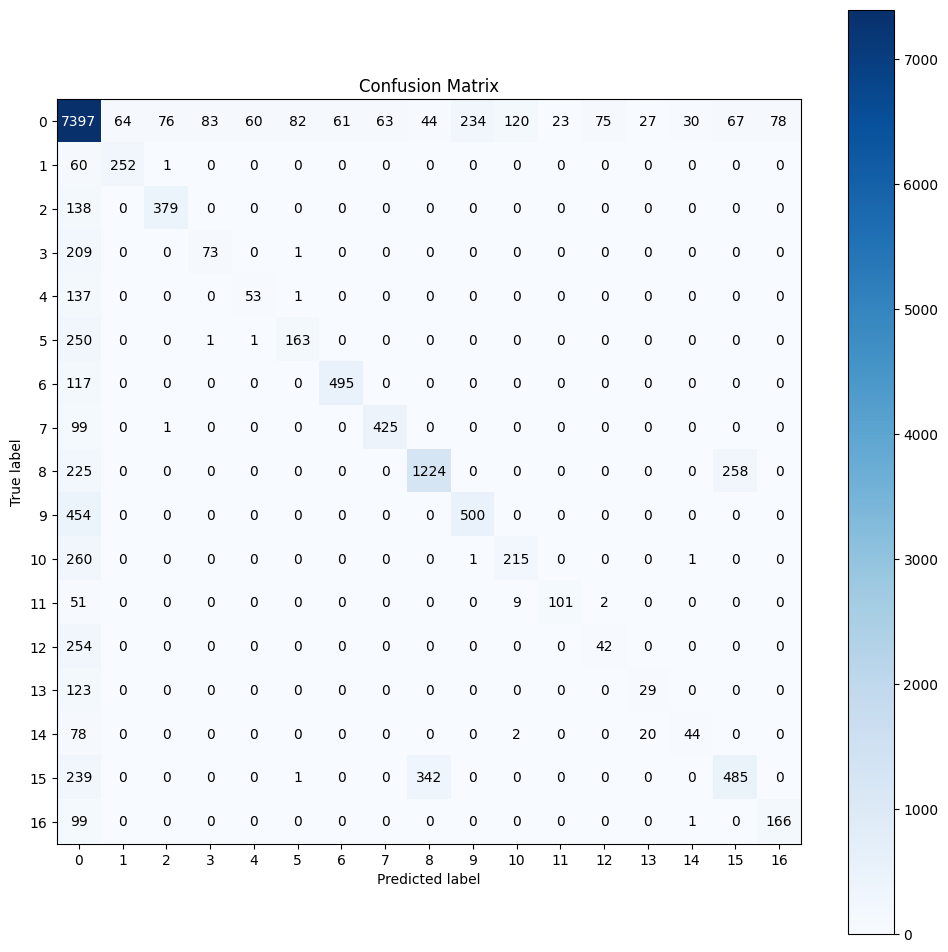

In [ ]:

skplt.metrics.plot_confusion_matrix(
    y_test,
    y_pred2,
    figsize=(12,12));

In [ ]:
# print(confusion_matrix(y_test,y_pred))
print('Classification report:\n',classification_report(y_test,y_pred2))

Classification report:
               precision    recall  f1-score   support

           0       0.73      0.86      0.79      8584
           1       0.80      0.81      0.80       313
           2       0.83      0.73      0.78       517
           3       0.46      0.26      0.33       283
           4       0.46      0.28      0.35       191
           5       0.66      0.39      0.49       415
           6       0.89      0.81      0.85       612
           7       0.87      0.81      0.84       525
           8       0.76      0.72      0.74      1707
           9       0.68      0.52      0.59       954
          10       0.62      0.45      0.52       477
          11       0.81      0.62      0.70       163
          12       0.35      0.14      0.20       296
          13       0.38      0.19      0.25       152
          14       0.58      0.31      0.40       144
          15       0.60      0.45      0.52      1067
          16       0.68      0.62      0.65       266

  

In [ ]:
pre2 = y_pred2

clmap2 = [0] * X.shape[0]

for i in tqdm(range(len(indices_train))):
    clmap2[indices_train[i]] = y[indices_train[i]]

for i in tqdm(range(len(indices_test))):
    clmap2[indices_test[i]] = pre2[i]

plt.figure(figsize=(8, 6))
plt.imshow(np.array(clmap2).reshape((512, 217)))
plt.colorbar()
plt.axis('off')
plt.title('Classification Map (PCA + SVC(kernel : sigmoid))')
plt.savefig('Classification_map_sigmoid.png')
plt.show()


##Apply SVC with C:2 kernel: 'poly' and Degree: 3 and gamma 'scale'


In [ ]:

svm3 = SVC(C=2.0, kernel='poly', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001 ,  cache_size=1024*7)
svm3.fit(X_train, y_train)

SVC(C=2.0, cache_size=7168, kernel='poly')

In [ ]:
y_pred3 = svm3.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred3)*100}%')


Accuracy: 90.48961958478338%


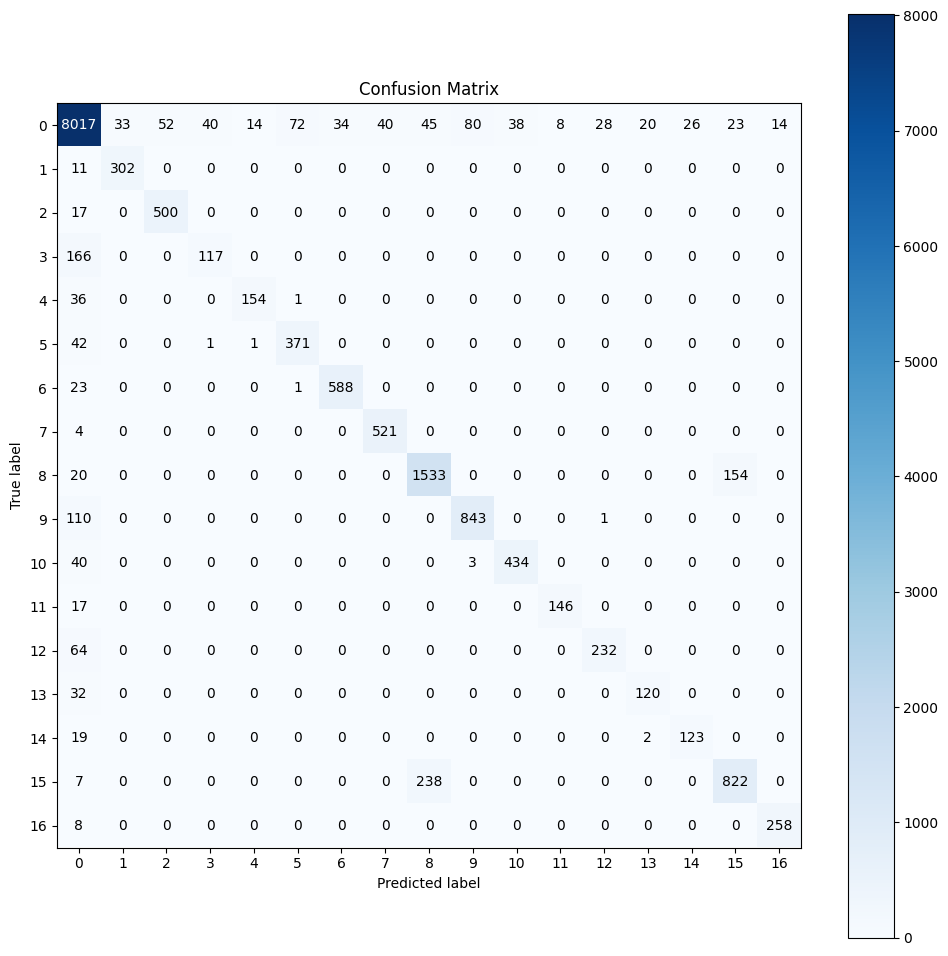

In [ ]:
skplt.metrics.plot_confusion_matrix(
    y_test,
    y_pred3,
    figsize=(12,12));

In [ ]:
# print(confusion_matrix(y_test,y_pred))
print('Classification report:\n',classification_report(y_test,y_pred3))

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      8584
           1       0.90      0.96      0.93       313
           2       0.91      0.97      0.94       517
           3       0.74      0.41      0.53       283
           4       0.91      0.81      0.86       191
           5       0.83      0.89      0.86       415
           6       0.95      0.96      0.95       612
           7       0.93      0.99      0.96       525
           8       0.84      0.90      0.87      1707
           9       0.91      0.88      0.90       954
          10       0.92      0.91      0.91       477
          11       0.95      0.90      0.92       163
          12       0.89      0.78      0.83       296
          13       0.85      0.79      0.82       152
          14       0.83      0.85      0.84       144
          15       0.82      0.77      0.80      1067
          16       0.95      0.97      0.96       266

  

In [ ]:
pre3 = y_pred3  # FIXED: was mistakenly set to y_pred2 (sigmoid predictions)

clmap3 = [0] * X.shape[0]

for i in tqdm(range(len(indices_train))):
    clmap3[indices_train[i]] = y[indices_train[i]]

for i in tqdm(range(len(indices_test))):
    clmap3[indices_test[i]] = pre3[i]  # FIXED: was mistakenly indexing pre2

plt.figure(figsize=(8, 6))
plt.imshow(np.array(clmap3).reshape((512, 217)))
plt.colorbar()
plt.axis('off')
plt.title('Classification Map (PCA + SVC(kernel:poly degree:3 c:2))')
plt.savefig('Classification_map_poly.png')
plt.show()


## compaire accuracy of each SVC

In [ ]:
print(f'Accuracy SVR1 Kkernel:rbf c:1 degree:11 gamma: scale      : {accuracy_score(y_test, y_pred)*100}%')

print(f'Accuracy SVR2 Kkernel:sigmoid c:1 degree:8 gamma: scale   : {accuracy_score(y_test, y_pred2)*100}%')

print(f'Accuracy SVR3 Kkernel:poly c:2 degree:11 gamma: scale     : {accuracy_score(y_test, y_pred3)*100}%')


Accuracy SVR1 Kkernel:rbf c:1 degree:11 gamma: scale      : 91.47365894635784%
Accuracy SVR2 Kkernel:sigmoid c:1 degree:8 gamma: scale   : 72.26089043561743%
Accuracy SVR3 Kkernel:poly c:2 degree:11 gamma: scale     : 90.48961958478338%
